In [4]:
'''
Giulia D'Angelo, giulia.dangelo@fel.cvut.cz

This script simulates the behavior of a Leaky Integrate-and-Fire (LIF) neuron model.
The LIF model is a simple yet effective representation of neuronal dynamics, capturing
essential features of spiking behavior. The simulation visualizes the neuron's membrane
potential over time in response to an external input current composed of short pulses.

'''

"\nGiulia D'Angelo, giulia.dangelo@fel.cvut.cz\n\nThis script simulates the behavior of a Leaky Integrate-and-Fire (LIF) neuron model.\nThe LIF model is a simple yet effective representation of neuronal dynamics, capturing\nessential features of spiking behavior. The simulation visualizes the neuron's membrane\npotential over time in response to an external input current composed of short pulses.\n\n"

# Tutorial 3 (A): Play with neurons

### __The Leaky-integrate-and-Fire neuron model__
Biological neurons communicate by generating brief electrical pulses called action potentials, or spikes. Understanding how and when a neuron fires is central to neuroscience and neuromorphic computing. The Leaky Integrate-and-Fire (LIF) model is one of the simplest mathematical descriptions that capture this spiking behavior.  

A neuron receives input from thousands of other neurons through synaptic connections. These inputs drive an electrical current across the cell membrane, gradually changing the neuron's membrane potential — the voltage difference between the inside and outside of the cell.
When the membrane potential reaches a critical value called the firing threshold, the neuron generates a spike and its potential abruptly resets to a resting value. This process — accumulate charge, fire, reset — is the core of neural computation.

__The governing equation of LIF neurons__  
The LIF model describes the evolution of the membrane potential $V(t)$ [mV] with a single differential equation:  

 $\tau_m \frac{dV(t)}{dt} = (V_L - V(t)) + R_m \cdot I_{ext}(t)$,  


where the membrane time constant $\tau_m$ [ms] controls how  $V$ changes, $V_L$ is the resting potential, $I_{ext}$ represents the input current and the membrane resistance $R_m$ [m $\Omega$] scales the effect of input current.  

The membrane time constant is set as:  

$\tau_m ​=\frac{C_m}​{g_L}$​,  
$R_m = \frac{1}{g_L}$,  

where $g_L$ is the leak conductance expressing how easily ions flow across the membrane at rest, high leak conductance means a strong leak, the mebrane potential returns to rest quickly and input current has less effect.  
$C_m$ is the membrane capacitance, it measures how much charge the membrane can store, with higher $C_m$ the membrane charges and discharges slowly, contrary lower $C_m$ lead the neuron to respond faster.

__Spiking Mechanism__  
The LIF model applies a simple firing rule and the spike itself is treated as an instantaneous event:  

if $V(t) \geq V_T$   
$\qquad \rightarrow$ record spike and reset $V(t)$ to resting potential $V_L$    

__Numerical Simulation__  
Because the LIF equation has no closed-form solution for arbitrary inputs, we simulate it numerically using Euler's method:  

$V(t + \Delta t) = V(t) + \Delta t \cdot \frac{dV}{dt}​$  


Despite its simplicity, the LIF model reproduces many key features of real neural dynamics: subthreshold integration, spike-rate adaptation, and frequency-current relationships. It is widely used in computational neuroscience and is the foundation of many neuromorphic hardware architectures.


### __Task 0: Get familiar__  
Play with the following simulation: In the code, the neuron is periodically stimulated by a current `I_ext` of amplitude `I_ext_amp`, influencing the membrane potential.    
Run the simulation with `I_ext_amp = 1.0`, then with `3.0` and `5.0`. Observe the membrane potential behaviour, its growth and the exponential leaky decay towards the resting potential value, when not stimulated. Notice the membrane potential dropping after crossing the firing threshold back to the Reset voltage (VR) value before increasing again.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import clear_output, display

In [31]:
# LIF parameters
Cm = 0.74          # Membrane capacitance (uF)
gL = 0.1           # Leak conductance (mS)
VL = -65.0         # Resting potential (mV)
VT = -50.0         # Threshold voltage (mV)
VR = -67.0         # Reset voltage (mV)
Rm = 1 / gL        # Membrane resistance (MΩ)
tau_m = Cm / gL    # Membrane time constant (ms)

# Time parameters
dt = 0.2           # Time step (ms)
T = 200            # Total simulation time (ms)
time = np.arange(0, T, dt)  # Create a time array

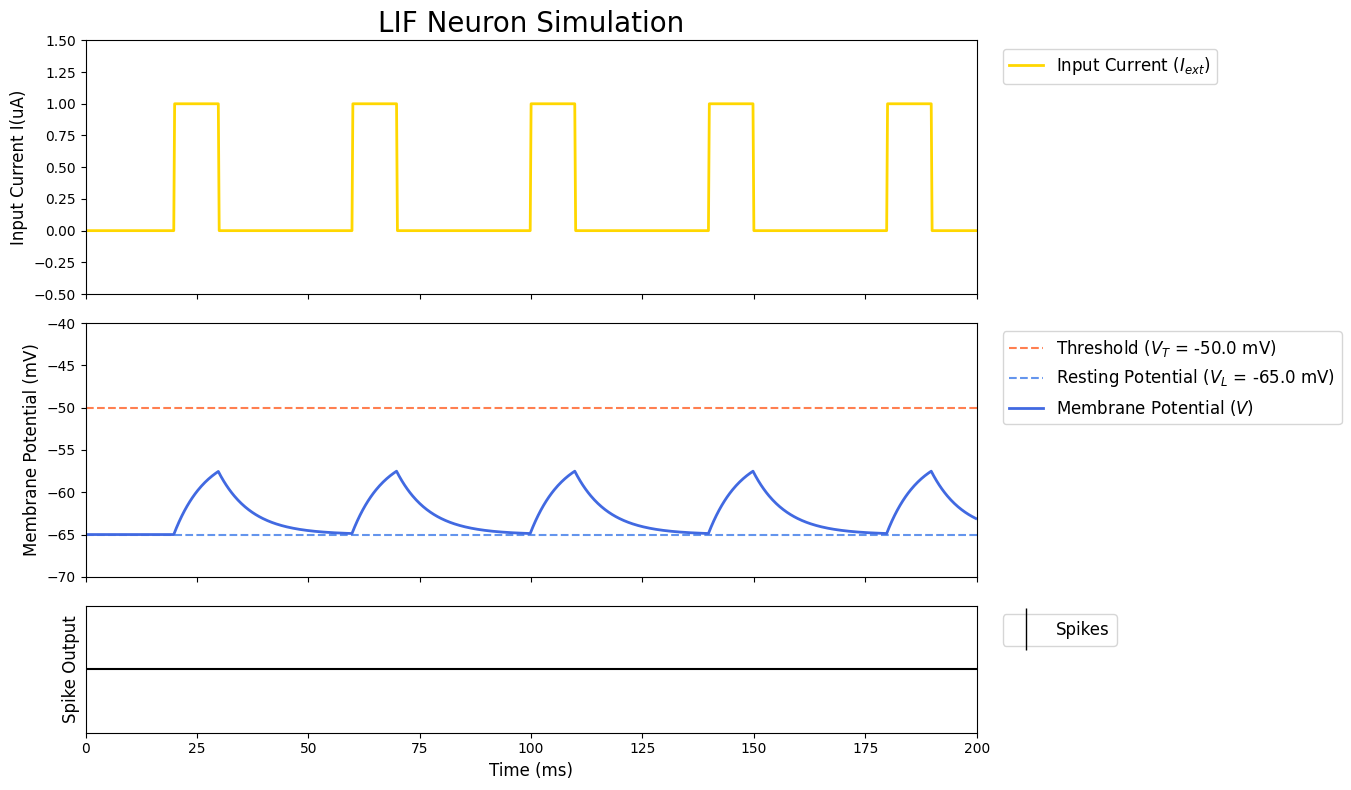

In [32]:
# Define input current
I_ext_amp = 1.0
I_ext = np.zeros_like(time)  # Initialize external current array
pulse_times = np.arange(20, T, 40)  # Define pulse start times
for t in pulse_times:
    I_ext[int(t/dt):int((t+10)/dt)] = I_ext_amp  # Create short pulses of current

# Initialize membrane potential
V = np.zeros_like(time)  # Membrane potential array
V[0] = VL  # Set initial potential to resting potential
display_V = V.copy()

# Create the figure that will be updated live inside the notebook
fig, ax = plt.subplots(
    3, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]}
)
# el. current plot
ax[0].set_xlim(0, T)
ax[0].set_ylim(-0.5, max(I_ext) + 0.5)
ax[0].set_ylabel("Input Current I(uA)", fontsize=12)
ax[0].set_title("LIF Neuron Simulation", fontsize=20)
line_I, = ax[0].plot([], [], lw=2, color='gold', label="Input Current ($I_{{ext}}$)")
ax[0].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))
# membrane potential plot
ax[1].set_xlim(0, T)
ax[1].set_ylim(-70, -40)
ax[1].set_ylabel("Membrane Potential (mV)", fontsize=12)
ax[1].axhline(y=VT, color='coral', linestyle='--', label=f"Threshold ($V_T$ = {VT} mV)")
ax[1].axhline(y=VL, color='cornflowerblue', linestyle='--', label=f"Resting Potential ($V_L$ = {VL} mV)")
line_V, = ax[1].plot([], [], lw=2,color ='royalblue', label="Membrane Potential ($V$)")
ax[1].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))
# spike raster plot
ax[2].set_xlim(0, T)
ax[2].set_ylim(0.8, 1.2)
ax[2].set_xlabel("Time (ms)", fontsize=12)
ax[2].set_ylabel("Spike Output", fontsize=12)
ax[2].set_yticks([])
ax[2].axhline(y=1.0, color='k', linestyle='-')
line_spikes, = ax[2].plot([], [], 'k|', markersize=30, label="Spikes")
ax[2].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))
spike_times = []
plt.tight_layout(rect=[0.1, 0, 0.95, 1]) 
for axis in ax:
    axis.tick_params(axis='both', which='major', labelsize=10)
display(fig)

# Simulation loop: update membrane potential and plot at each time step
for i in range(1, len(time)):
    # Calculate change in membrane potential (dV/dt) based on leak and input current
    dVdt = ((VL - V[i-1]) + Rm * I_ext[i]) / tau_m
    V[i] = V[i-1] + dVdt * dt # Update membrane potential using Euler's method (solving the differential equation)
    display_V[i] = V[i]
    fired = False
    # Check if the potential exceeds the threshold to generate a spike
    if V[i] >= VT:
        V[i] = VR
        display_V[i] = VT
        fired = True
        if i + 1 < len(time):
            V[i + 1] = VR

    if fired:
        spike_times.append(time[i])

    # Update the plotted data with the latest simulation state
    line_I.set_data(time[:i + 1], I_ext[:i + 1])
    line_spikes.set_data(spike_times, np.ones(len(spike_times)))
    line_V.set_data(time[:i + 1], display_V[:i + 1])

    clear_output(wait=True)
    display(fig)
    plt.pause(0.001)

_Additional exploration prompt:_   
_What happens if you modify the LIF parameters, such as Cm, gL, or VT? Experiment by increasing or decreasing these values and observe how the membrane potential and spiking behavior change in the animation._ 

### __Task 1: Refractory period__  
In the visualisation of task 0, you may have noticed that after the spike, the neuron is immediately ready to spike again. However, in biological neurons it is not possible. There is the so-called __refractory period__, time required to establish ion equillibrium within the cell again, during which no firing is possible. In the following example refractory period of $\tau_{ref} = 2.0$ ms is implemented.   
Run the script and observe the effect of the refractory period on the firing rate. 

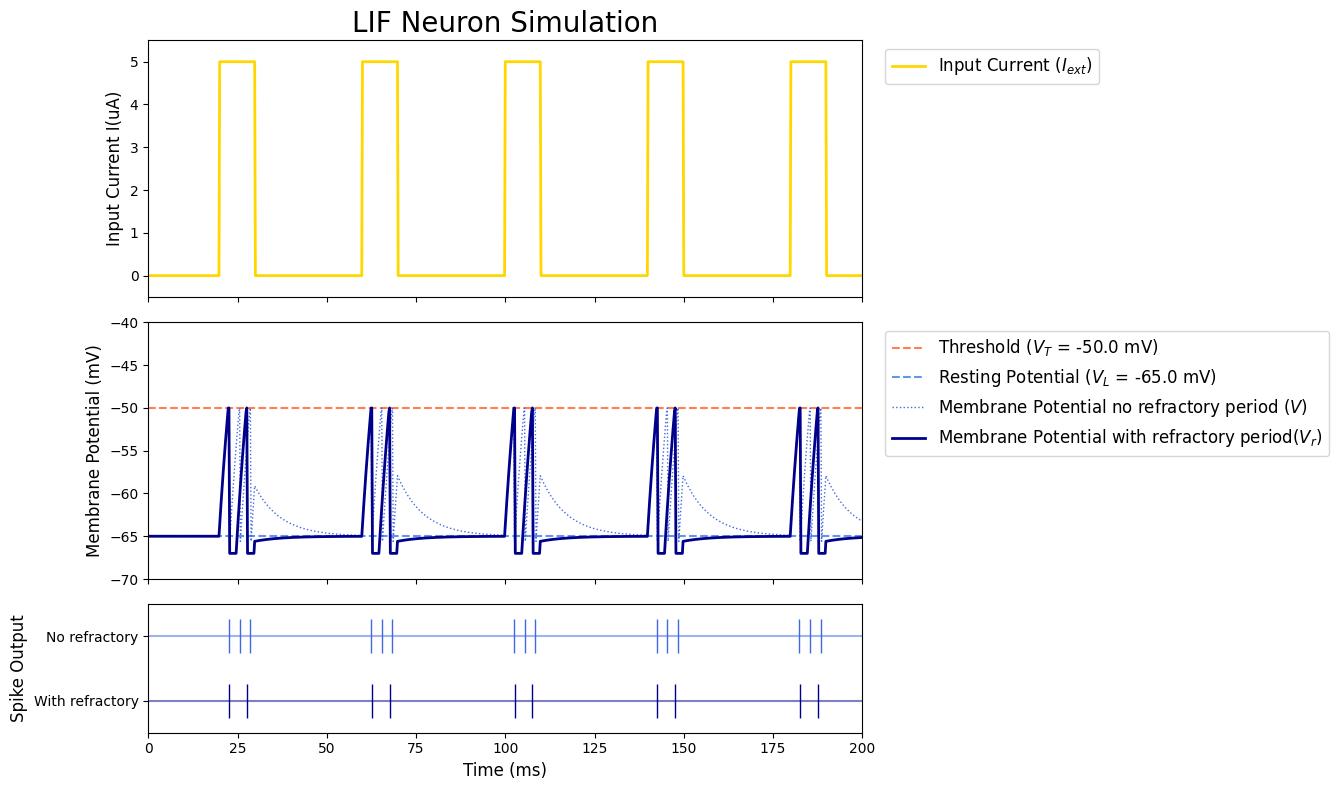

In [33]:
# Refractory settings
t_ref = 2.0  # ms
ref_steps = int(np.round(t_ref / dt))
ref_count = 0  # Counter to track refractory period

# Define input current
I_ext_amp = 5.0
I_ext = np.zeros_like(time)  # Initialize external current array
pulse_times = np.arange(20, T, 40)  # Define pulse start times
for t in pulse_times:
    I_ext[int(t/dt):int((t+10)/dt)] = I_ext_amp  # Create short pulses of current

# Initialize membrane potentials
V = np.zeros_like(time)  # Membrane potential as before
V[0] = VL  
display_V = V.copy()

V_r = np.zeros_like(time)  # Membrane potential refractory period
V_r[0] = VL  
display_V_r = V_r.copy()


# Create the figure that will be updated live inside the notebook
fig, ax = plt.subplots(
    3, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]}
)
# el. current plot
ax[0].set_xlim(0, T)
ax[0].set_ylim(-0.5, max(I_ext) + 0.5)
ax[0].set_ylabel("Input Current I(uA)", fontsize=12)
ax[0].set_title("LIF Neuron Simulation", fontsize=20)
line_I, = ax[0].plot([], [], lw=2, color='gold', label="Input Current ($I_{{ext}}$)")
ax[0].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))
# membrane potential plot
ax[1].set_xlim(0, T)
ax[1].set_ylim(-70, -40)
ax[1].set_ylabel("Membrane Potential (mV)", fontsize=12)
ax[1].axhline(y=VT, color='coral', linestyle='--', label=f"Threshold ($V_T$ = {VT} mV)")
ax[1].axhline(y=VL, color='cornflowerblue', linestyle='--', label=f"Resting Potential ($V_L$ = {VL} mV)")
line_V, = ax[1].plot([], [], lw=1,color ='royalblue', linestyle=':', label="Membrane Potential no refractory period ($V$)")
line_V_r, = ax[1].plot([], [], lw=2,color ='darkblue', label="Membrane Potential with refractory period($V_r$)")
ax[1].legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))
# spike raster plot
y_no_ref = 1.06
y_ref = 0.94

ax[2].set_xlim(0, T)
ax[2].set_ylim(0.88, 1.12)
ax[2].set_xlabel("Time (ms)", fontsize=12)
ax[2].set_ylabel("Spike Output", fontsize=12)

# optional: show labels for the two tracks
ax[2].set_yticks([y_no_ref, y_ref])
ax[2].set_yticklabels(["No refractory", "With refractory"])

# horizontal guide lines, one per case
ax[2].axhline(y=y_no_ref, color="royalblue", linestyle="-", alpha=0.5)
ax[2].axhline(y=y_ref, color="darkblue", linestyle="-", alpha=0.5)

line_spikes, = ax[2].plot([], [], "|", color="royalblue", markersize=24, label="Spikes no refractory period")
line_spikes_r, = ax[2].plot([], [], "|", color="darkblue", markersize=24, label="Spikes with refractory period")

spike_times = []
spike_times_r = []
plt.tight_layout(rect=[0.1, 0, 0.95, 1]) 
for axis in ax:
    axis.tick_params(axis='both', which='major', labelsize=10)
display(fig)

# Simulation loop: update membrane potential and plot at each time step
for i in range(1, len(time)):
    # Loop for no-refractory period case
    fired = False
    dVdt = ((VL - V[i - 1]) + Rm * I_ext[i]) / tau_m
    V[i] = V[i - 1] + dVdt * dt
    display_V[i] = V[i]
    # Check if the potential exceeds the threshold to generate a spike
    if V[i] >= VT:
        V[i] = VR
        display_V[i] = VT
        fired = True
        if i + 1 < len(time):
            V[i + 1] = VR
    if fired:
        spike_times.append(time[i])

    # Loop for no-refractory period case
    fired_r = False
    if ref_count > 0: # Absolute refractory period: hold at reset, skip integration
        V_r[i] = VR
        display_V_r[i] = VR
        ref_count -= 1
    else:
        dVdt = ((VL - V_r[i - 1]) + Rm * I_ext[i]) / tau_m
        V_r[i] = V_r[i - 1] + dVdt * dt
        display_V_r[i] = V_r[i]

        if V_r[i] >= VT:
            V_r[i] = VR
            display_V_r[i] = VT
            fired_r = True
            ref_count = ref_steps  # start refractory period
            if i + 1 < len(time):
                V_r[i + 1] = VR
    if fired_r:
        spike_times_r.append(time[i])

    # Update the plotted data with the latest simulation state
    line_I.set_data(time[:i + 1], I_ext[:i + 1])
    line_spikes.set_data(spike_times, np.ones(len(spike_times)))
    line_spikes_r.set_data(spike_times_r, np.ones(len(spike_times_r)))
    # Update the plotted data with the latest simulation state
    line_I.set_data(time[:i + 1], I_ext[:i + 1])
    line_spikes.set_data(
        spike_times,
        np.full(len(spike_times), y_no_ref)   # no refractory track
    )
    line_spikes_r.set_data(
        spike_times_r,
        np.full(len(spike_times_r), y_ref)    # refractory track
    )
    line_V_r.set_data(time[:i + 1], display_V_r[:i + 1])
    line_V.set_data(time[:i + 1], display_V[:i + 1])

    clear_output(wait=True)
    display(fig)
    plt.pause(0.001)

### __Task 2: Find the minimum firing current.__  
Now, let's replace the pulsed input with a constant current $I_{ext}$. Find the minimal constant current $I_{min}$ which causes the neuron to fire at least once.   

__LIF Neuron equation:__  $$\tau_m \frac{dV(t)}{dt} = (V_L - V(t)) + R_m \cdot I_{ext}(t)$$


_Hint:_ With constant current $\frac{dV(t)}{dt} = 0$, spiking condition: $V(t) = V_T$ (threshold).

In [ ]:
#TODO solve for I_min here
I_min = None
print(f"Minimum input current required to reach threshold: {I_min:.2f} uA")

In [ ]:
# condition for firing: VT = V(t) 
# governing equation: tau_m * dV/dt = VL - V(t) + Rm * I_ext 
# apply dV/dt = 0: V(t) = VL + Rm * I_ext = VT

# solving for I_ext: I_ext = (VT - VL) / Rm
I_min = (VT - VL) / Rm
print(f"Minimum input current required to reach threshold: {I_min:.2f} uA")

### __Task 3: Explore the firing rate__  
Let's keep the constant driving current and observe how the current amplitude influences the firing rate of the neuron.   
The firing rate is defined as: _num_spikes_ / _sec_.    

Adapt the above code to feed the neuron a constant external current $I_{ext}$.  
For $I_{ext}$ use 10 equidistant values from interval [$I_{min},18$], where $I_{min}$ is your result from task 1.   
Keep the original time parameters (simulation duration etc.).  
For each driving current, collect the number of produced spikes for both no-refractory-period and with-refractory-period scenarios and finally use _{num_spikes}_/_{total_simulation_time[sec]}_ to get the per-second firing rates.   

Plot both the no-refractory-period and with-refractory-period firing rates in respect to input current amplitude $I_{ext}$.   

What is the difference in the spike rates with and without refractory period for $I_{ext} = 18$ $\mu A$?

In [ ]:
#TODO 

firing_rate = None
firing_rate_r = None
print(f"Difference in Firing rates: {firing_rate[-1] -firing_rate_r[-1]} spikes/sec at I_ext = 18 uA.")

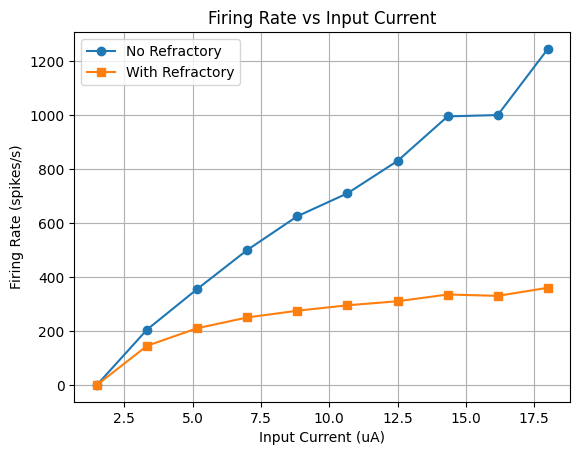

Difference in Firing rates: 885.0 spikes/sec.


In [ ]:
currents = np.linspace(1.5, 18.0, 10)
num_spikes = []
num_spikes_r = []

for I_ext_amp in currents:
    # Define input current
    I_ext = I_ext_amp * np.ones_like(time)  # Initialize constatnt current array

    # Initialize membrane potential
    V = np.zeros_like(time)  # Membrane potential array
    V[0] = VL  # Set initial potential to resting potential
    spike_times = []
    V_r = np.zeros_like(time)  # Membrane potential refractory period
    V_r[0] = VL  
    spike_times_r = []

    # Simulation loop: update membrane potential and plot at each time step
    for i in range(1, len(time)):
        # Calculate change in membrane potential (dV/dt) based on leak and input current
        dVdt = ((VL - V[i-1]) + Rm * I_ext[i]) / tau_m
        V[i] = V[i-1] + dVdt * dt # Update membrane potential using Euler's method (solving the differential equation)
        fired = False
        # Check if the potential exceeds the threshold to generate a spike
        if V[i] >= VT:
            V[i] = VR
            fired = True
            if i + 1 < len(time):
                V[i + 1] = VR

        if fired:
            spike_times.append(time[i])
    num_spikes.append(len(spike_times))

    # Simulate refractory period case
    for i in range(1, len(time)):
        if ref_count > 0:
            V_r[i] = VR
            ref_count -= 1
        else:
            dVdt = ((VL - V_r[i-1]) + Rm * I_ext[i]) / tau_m
            V_r[i] = V_r[i-1] + dVdt * dt
            fired_r = False
            if V_r[i] >= VT:
                V_r[i] = VR
                fired_r = True
                ref_count = ref_steps
                if i + 1 < len(time):
                    V_r[i + 1] = VR
            if fired_r:
                spike_times_r.append(time[i])
    num_spikes_r.append(len(spike_times_r))

firing_rate = num_spikes / (T / 1000 * np.ones_like(num_spikes))
firing_rate_r = num_spikes_r / (T / 1000 * np.ones_like(num_spikes_r))
fig = plt.plot(currents, firing_rate, marker='o', label='No Refractory')
plt.plot(currents, firing_rate_r, marker='s', label='With Refractory')
plt.xlabel('Input Current (uA)')
plt.ylabel('Firing Rate (spikes/s)')
plt.title('Firing Rate vs Input Current')
plt.grid(True)
plt.legend()
plt.show()

print(f"Difference in Firing rates: {firing_rate[-1] -firing_rate_r[-1]} spikes/sec at I_ext = 18 uA.")